## Ejercicio de Tokenización PLATZI

### Carga del modelo pre entrenado Word2Vec

In [1]:
import gensim.downloader as api
model = api.load("word2vec-google-news-300")
print(len(model["wife"]))
model["wife"]

300


array([ 3.93066406e-02, -1.96289062e-01, -1.06445312e-01, -2.68554688e-02,
        9.71679688e-02,  9.91210938e-02, -5.88378906e-02, -2.75390625e-01,
        1.11816406e-01, -8.15429688e-02,  2.53906250e-01, -3.49609375e-01,
       -2.69531250e-01, -2.06298828e-02, -3.29589844e-02,  2.39257812e-01,
        2.18505859e-02,  1.29882812e-01, -5.95092773e-03,  1.57226562e-01,
        1.34277344e-02, -9.08203125e-02,  2.46093750e-01, -7.37304688e-02,
        7.27539062e-02, -1.43554688e-01, -2.02148438e-01,  2.28515625e-01,
       -1.42578125e-01, -7.47070312e-02,  1.74804688e-01, -5.66406250e-02,
       -1.77734375e-01,  9.32617188e-02,  6.21795654e-04,  7.12890625e-02,
        2.53906250e-01,  3.78417969e-02,  3.17382812e-02, -8.74023438e-02,
        1.27929688e-01, -1.40625000e-01,  2.05078125e-01, -6.64062500e-02,
       -2.36511230e-03, -1.29882812e-01, -4.88281250e-02,  5.03540039e-03,
       -1.91650391e-02,  6.59179688e-02, -1.05468750e-01, -4.91333008e-03,
        1.85546875e-01,  

### Gráfica de embeddings

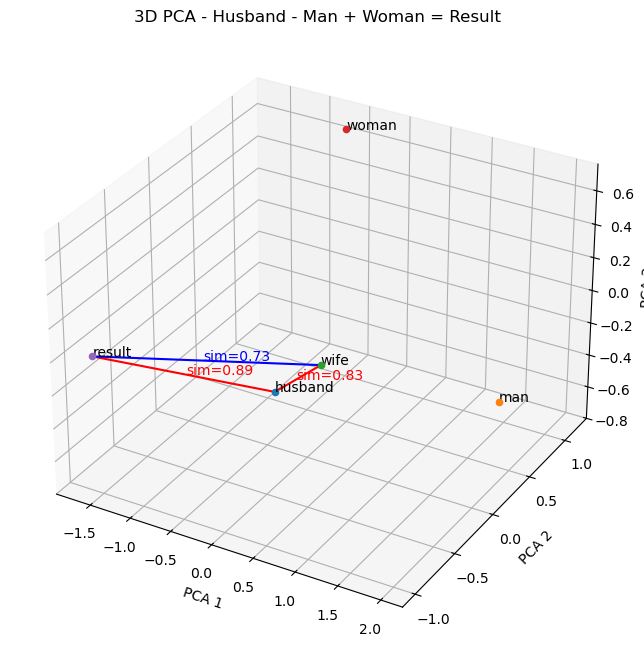

In [3]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

v_husband = model['husband']
v_man = model['man']
v_woman = model['woman']
v_wife = model['wife']
v_result = v_husband - v_man + v_woman

words_to_plot = ['husband', 'man', 'wife', 'woman', 'result']
vectors_to_plot = [v_husband, v_man, v_woman, v_wife, v_result]

pca = PCA(n_components = 3)
reduced = pca.fit_transform(vectors_to_plot) # Reducción de dimensionalidad
coords = {word: reduced[i] for i, word in enumerate(words_to_plot)}

def cos(a, b):
  return cosine_similarity([a], [b])[0, 0]

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection='3d')

for word, vec in coords.items():
  ax.scatter(vec[0], vec[1], vec[2])
  ax.text(vec[0], vec[1], vec[2], word)

result = coords['result']
husband = coords['husband']
wife = coords['wife']

# Result <-> Husband
ax.plot([result[0], husband[0]], [result[1], husband[1]], [result[2], husband[2]], color='red')
mid_rh = (result + husband) / 2.0
ax.text(mid_rh[0], mid_rh[1], mid_rh[2],
        f"sim={cos(v_result, v_husband):.2f}", color='red')

# Husband <-> Wife
ax.plot([husband[0], wife[0]], [husband[1], wife[1]], [husband[2], wife[2]], color='red')
mid_hw = (husband + wife) / 2.0
ax.text(mid_hw[0], mid_hw[1], mid_hw[2],
        f"sim={cos(v_husband, v_wife):.2f}", color='red')

# Result <-> Wife
ax.plot([result[0], wife[0]], [result[1], wife[1]], [result[2], wife[2]], color='blue')
mid_rw = (result + wife) / 2.0 # Corrected: renamed to mid_rw for clarity
ax.text(mid_rw[0], mid_rw[1], mid_rw[2], # Corrected: used mid_rw
        f"sim={cos(v_result, v_wife):.2f}", color='blue')

ax.set_title("3D PCA - Husband - Man + Woman = Result")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2"); ax.set_zlabel("PCA 3")
plt.show()

### Palabras más similares

Operación husband - man + woman

In [ ]:
similar_words = model.most_similar(positive=[v_result], topn=10)

print("Top 10 palabras más similares a la operación 'husband - man + woman':")
for word, similarity in similar_words:
  print(f"{word}: {similarity:.4f}")

Top 10 palabras más similares a la operación 'husband - man + woman':
husband: 0.8853
mother: 0.7417
wife: 0.7333
daughter: 0.7246
niece: 0.6421
fiancé: 0.6409
hus_band: 0.6335
fiance: 0.6323
daughters: 0.6309
eldest_daughter: 0.6298


Wife

In [6]:
similar_words = model.most_similar(positive=[v_wife], topn=10)

print("Top 10 palabras más similares a la operación 'wife':")
for word, similarity in similar_words:
  print(f"{word}: {similarity:.4f}")

Top 10 palabras más similares a la operación 'wife':
wife: 1.0000
husband: 0.8294
daughter: 0.7662
fiancée: 0.7583
mother: 0.7551
fiancee: 0.7449
daughters: 0.7342
girlfriend: 0.7102
niece: 0.7086
estranged_wife: 0.7018


Husband

In [7]:
similar_words = model.most_similar(positive=[v_husband], topn=10)

print("Top 10 palabras más similares a la operación 'husband':")
for word, similarity in similar_words:
  print(f"{word}: {similarity:.4f}")

Top 10 palabras más similares a la operación 'husband':
husband: 1.0000
wife: 0.8294
mother: 0.7414
father: 0.7408
daughter: 0.7384
fiancé: 0.7354
fiance: 0.7344
son: 0.7241
boyfriend: 0.6960
hus_band: 0.6928
